In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
from pathlib import Path

# Ruta raíz del proyecto en Drive
PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models")

# Carpetas principales
NOTEBOOKS_DIR = PROJECT_PATH / "notebooks"
SRC_DIR = PROJECT_PATH / "src"
CHECKPOINTS_DIR = PROJECT_PATH / "checkpoints"
RESULTS_DIR = PROJECT_PATH / "results"

# Añadir src al path para poder importar los .py
sys.path.insert(0, str(SRC_DIR))

# Crear carpetas si no existen
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_PATH =", PROJECT_PATH)
print("SRC_DIR =", SRC_DIR)
print("CHECKPOINTS_DIR =", CHECKPOINTS_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_PATH = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
SRC_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src
CHECKPOINTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints
RESULTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/results


# Training a Brownian-motion diffusion model on MNIST

This auxiliary notebook is used to train a higher-quality score-based diffusion model on MNIST using the Brownian motion (variance exploding) forward process. The trained checkpoint will later be reused in the main notebook for sample generation with the Euler–Maruyama integrator.

In [ ]:
import os
from functools import partial

import torch
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
from tqdm.notebook  import trange

from score_model import ScoreNet
from diffusion_utilities import plot_image_grid, plot_image_evolution
from bm_utils import (
    bm_sigma_t,
    build_bm_diffusion_process,
    sample_bm_euler_maruyama,
    sample_bm_predictor_corrector,
    sample_bm_probability_flow_ode,
    compute_log_likelihood_ode
)

In [ ]:
# Reproducibility
_ = torch.manual_seed(123)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Paths
checkpoint_path = CHECKPOINTS_DIR / "bm_mnist_digit3_best.pth"
print("Checkpoint path:", checkpoint_path)

Device: cpu
Checkpoint path: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/bm_mnist_digit3_best.pth


In [ ]:
# Load MNIST
data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Keep only one digit class to simplify the problem
digit = 3
indices_digit = torch.where(data.targets == digit)[0]
data_train = Subset(data, indices_digit)

print("Training subset size:", len(data_train))

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 605kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.28MB/s]

Training subset size: 6131


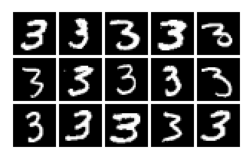

In [ ]:
n_rows = 3
n_cols = 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize=(3, 3),
    n_rows=n_rows,
    n_cols=n_cols,
)

In [ ]:
batch_size = 64

data_loader = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=torch.get_num_threads(),
)

images_0 shape: torch.Size([64, 1, 28, 28])
images_t_vis shape: torch.Size([64, 1, 28, 28, 201])


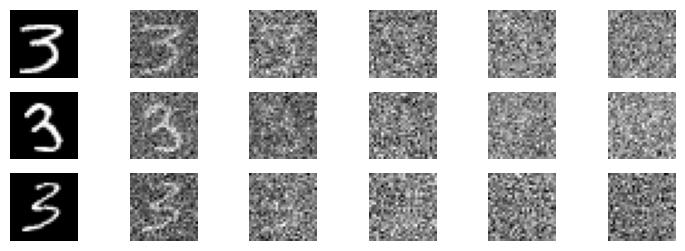

In [ ]:
# Forward diffusion with Brownian motion
import diffusion_process as dfp

# Take one mini-batch to illustrate the forward process
images_0, _ = next(iter(data_loader))
print("images_0 shape:", images_0.shape)

# Brownian motion forward SDE
sigma_vis = 25.0

def bm_drift_coefficient(x_t, t):
    return torch.zeros_like(x_t)

def bm_diffusion_coefficient(t, sigma):
    return sigma**t

t_0 = 0.0
t_end = 1.0
n_steps_vis = 200

times_vis, images_t_vis = dfp.euler_maruyama_integrator(
    images_0,
    t_0,
    t_end,
    n_steps_vis,
    drift_coefficient=bm_drift_coefficient,
    diffusion_coefficient=partial(bm_diffusion_coefficient, sigma=sigma_vis),
)

print("images_t_vis shape:", images_t_vis.shape)

_ = plot_image_evolution(
    images=images_t_vis,
    n_images=3,
    n_intermediate_steps=[0, 20, 50, 100, 150, 199],
    figsize=(9, 3),
)

In [ ]:
sigma = 25.0
diffusion_process = build_bm_diffusion_process(sigma=sigma)

In [ ]:
score_model = torch.nn.DataParallel(
    ScoreNet(
        marginal_prob_std=partial(bm_sigma_t, sigma=sigma)
    )
).to(device)

print(score_model)

DataParallel(
  (module): ScoreNet(
    (embed): Sequential(
      (0): GaussianRandomFourierFeatures()
      (1): Linear(in_features=256, out_features=256, bias=True)
    )
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (dense1): Dense(
      (dense): Linear(in_features=256, out_features=32, bias=True)
    )
    (gnorm1): GroupNorm(4, 32, eps=1e-05, affine=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense2): Dense(
      (dense): Linear(in_features=256, out_features=64, bias=True)
    )
    (gnorm2): GroupNorm(32, 64, eps=1e-05, affine=True)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense3): Dense(
      (dense): Linear(in_features=256, out_features=128, bias=True)
    )
    (gnorm3): GroupNorm(32, 128, eps=1e-05, affine=True)
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (dense4): Dense(
      (dense): Linear(in_features=256, out_features=

In [ ]:

checkpoint = torch.load(checkpoint_path, map_location=device)
score_model.load_state_dict(checkpoint)
score_model.eval()

print("Checkpoint loaded correctly from:", checkpoint_path)

Checkpoint loaded correctly from: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/bm_mnist_digit3_best.pth


In [ ]:
learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

n_epochs = 80
best_loss = float("inf")
loss_history = []

tqdm_epoch = trange(n_epochs)

for epoch in tqdm_epoch:
    score_model.train()
    avg_loss = 0.0
    num_items = 0

    for x, _ in data_loader:
        x = x.to(device)

        loss = diffusion_process.loss_function(score_model, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    loss_history.append(epoch_loss)

    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:8.5f}")

    # Save the best checkpoint
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(score_model.state_dict(), checkpoint_path)

  0%|          | 0/80 [00:00<?, ?it/s]

In [ ]:
score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
score_model.eval()

print("Loaded checkpoint:", checkpoint_path)

Loaded checkpoint: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/bm_mnist_digit3_best.pth


In [ ]:
n_images = 9

times, synthetic_images_t = sample_bm_euler_maruyama(
    score_model=score_model,
    sigma=sigma,
    n_images=n_images,
    image_shape=(1, 28, 28),
    T=1.0,
    t_end=1.0e-3,
    n_steps=500,
    device=device,
)

print(synthetic_images_t.shape)

torch.Size([9, 1, 28, 28, 501])


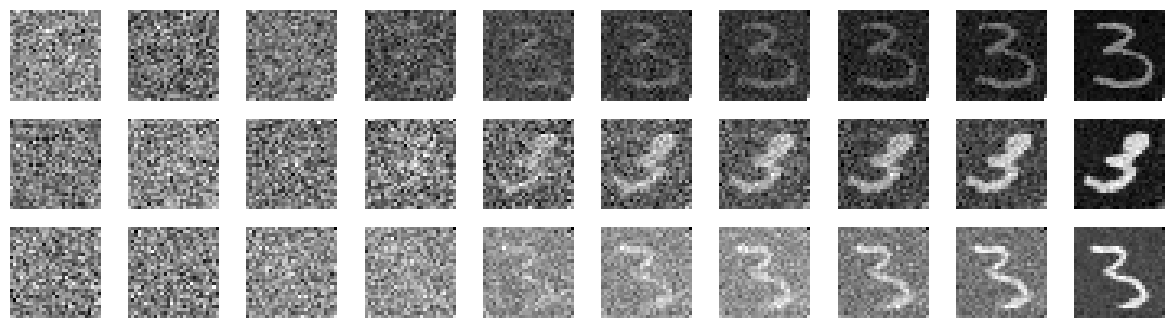

In [ ]:
_ = plot_image_evolution(
    images=synthetic_images_t,
    n_images=3,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

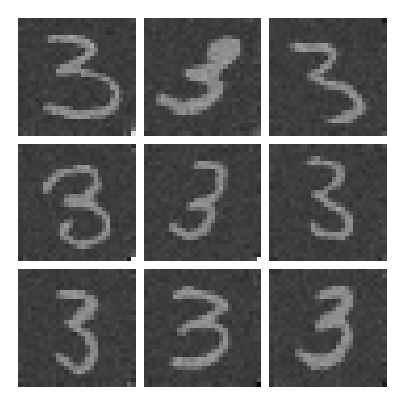

In [ ]:
final_images = synthetic_images_t[..., -1]

_ = plot_image_grid(
    images=[final_images[i] for i in range(n_images)],
    figsize=(5, 5),
    n_rows=3,
    n_cols=3,
    normalize=True,
)

torch.Size([9, 1, 28, 28, 501])


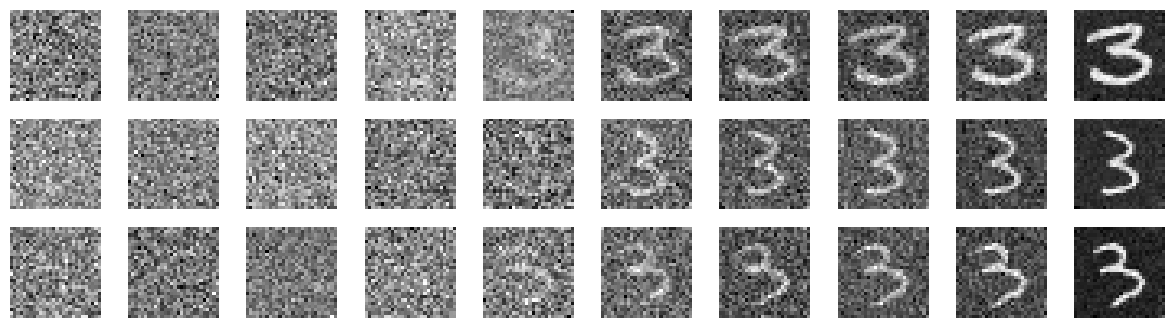

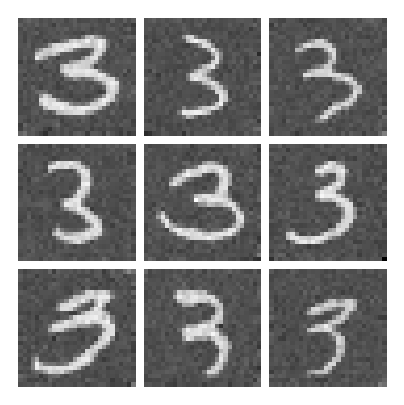

In [ ]:
n_images = 9

times_pc, synthetic_images_t_pc = sample_bm_predictor_corrector(
    score_model=score_model,
    sigma=sigma,
    n_images=n_images,
    image_shape=(1, 28, 28),
    T=1.0,
    t_end=1.0e-3,
    n_steps=500,
    n_corrector_steps=1,
    snr=0.16,
    device=device,
)

print(synthetic_images_t_pc.shape)

_ = plot_image_evolution(
    images=synthetic_images_t_pc,
    n_images=3,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

final_images_pc = synthetic_images_t_pc[..., -1]

_ = plot_image_grid(
    images=[final_images_pc[i] for i in range(n_images)],
    figsize=(5, 5),
    n_rows=3,
    n_cols=3,
    normalize=True,
)

torch.Size([9, 1, 28, 28, 501])


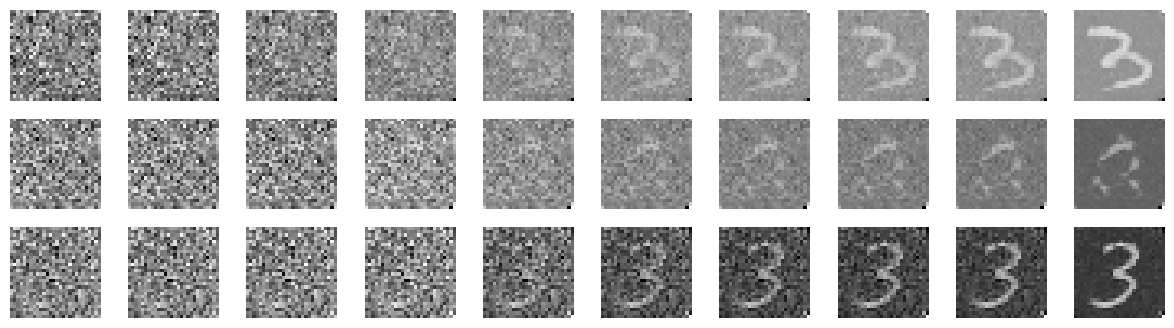

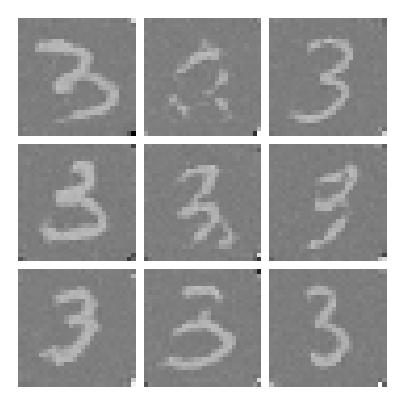

In [ ]:
n_images = 9

times_ode, synthetic_images_t_ode = sample_bm_probability_flow_ode(
    score_model=score_model,
    sigma=sigma,
    n_images=n_images,
    image_shape=(1, 28, 28),
    T=1.0,
    t_end=1.0e-3,
    n_steps=500,
    device=device,
)

print(synthetic_images_t_ode.shape)

_ = plot_image_evolution(
    images=synthetic_images_t_ode,
    n_images=3,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

final_images_ode = synthetic_images_t_ode[..., -1]

_ = plot_image_grid(
    images=[final_images_ode[i] for i in range(n_images)],
    figsize=(5, 5),
    n_rows=3,
    n_cols=3,
    normalize=True,
)

In [ ]:
images_eval, _ = next(iter(data_loader))
images_eval = images_eval[:8].to(device)

log_p, times_ll, x_t_ll = compute_log_likelihood_ode(
    x_0=images_eval,
    score_model=score_model,
    sigma=sigma,
    T=1.0,
    n_steps=50,
    eps=1.0e-3,
)

print("Estimated log-likelihoods:")
print(log_p)

print("Mean log-likelihood:", log_p.mean().item())

Estimated log-likelihoods:
tensor([4973.9771, 5835.1553, 5010.4268, 5991.6899, 5953.2627, 4935.7280,
        5917.4297, 5373.7334], grad_fn=<AddBackward0>)
Mean log-likelihood: 5498.92578125


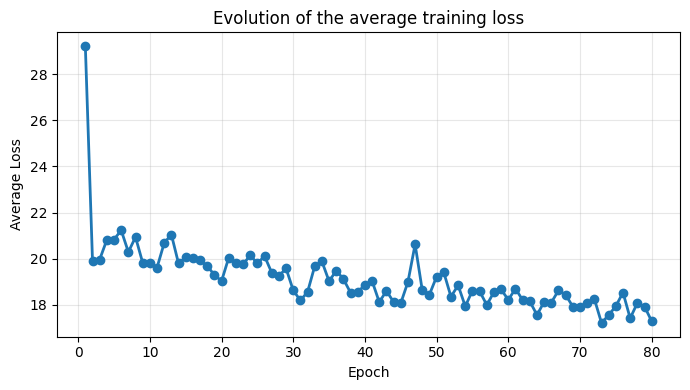

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Evolution of the average training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()